# Data Cleaning

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/TelcoCustomerChurn.csv')
print("Original Shape:", df.shape)

Original Shape: (7043, 21)


In [15]:
# Replace empty strings with NaN then convert
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verify
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("NaN count:", df['TotalCharges'].isnull().sum())

TotalCharges dtype: float64
NaN count: 11


In [3]:
null_rows = df[df['TotalCharges'].isnull()]
print("Null TotalCharges rows:")
print(null_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Null TotalCharges rows:
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


In [4]:
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after dropping nulls:", df.shape)  # Expected: (7032, 21)
print("Remaining nulls:\n", df.isnull().sum().sum())

Shape after dropping nulls: (7032, 21)
Remaining nulls:
 0


In [5]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
print("SeniorCitizen unique:", df['SeniorCitizen'].unique())

SeniorCitizen unique: ['No' 'Yes']


In [6]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn unique:", df['Churn'].unique())
print("Churn distribution:\n", df['Churn'].value_counts())

Churn unique: [0 1]
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [7]:
dupes = df.duplicated().sum()
print("Duplicate rows:", dupes)

if dupes > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicates found.")

Duplicate rows: 0
No duplicates found.


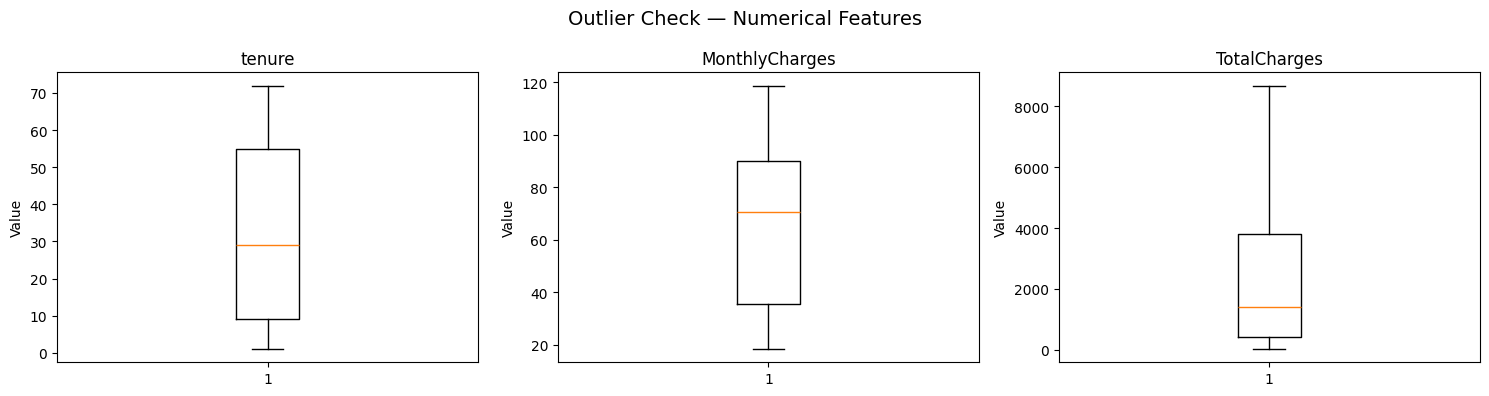

tenure: Q1=9.0, Q3=55.0, IQR=46.0, Outliers=0
MonthlyCharges: Q1=35.6, Q3=89.9, IQR=54.3, Outliers=0
TotalCharges: Q1=401.4, Q3=3794.7, IQR=3393.3, Outliers=0


In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Check — Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/outlier_check.png', dpi=150)
plt.show()

# IQR summary
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, Outliers={outliers}")

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = df[col].unique()
    print(f"{col} ({len(vals)}): {sorted(vals)}")

customerID (7032): ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-PEGZZ', 

In [10]:
df.to_csv('../data/cleaned_churn.csv', index=False)
print("Saved → data/cleaned_churn.csv")

Saved → data/cleaned_churn.csv
